In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

class KMeansClustering:
    def __init__(self):
        self.df = None
        self.scaler = None
        self.kmeans_model = None
        self.scaled_data = None
        self.feature_columns = None
        
    def load_data(self, file_path):
        """Đọc dữ liệu từ file CSV"""
        try:
            self.df = pd.read_csv(file_path)
            print(f"Dữ liệu được tải thành công. Kích thước: {self.df.shape}")
            print(f"Các cột trong dataset: {list(self.df.columns)}")
            return self.df.head()
        except Exception as e:
            print(f"Lỗi khi đọc file: {e}")
            return None
    
    def explore_data(self):
        """Khám phá dữ liệu cơ bản"""
        if self.df is None:
            print("Chưa có dữ liệu. Vui lòng tải dữ liệu trước.")
            return
        
        print("=" * 60)
        print("THONG TIN DU LIEU")
        print("=" * 60)
        
        # Thông tin cơ bản
        print(f"Kich thuoc du lieu: {self.df.shape}")
        print(f"\nKieu du lieu:")
        print(self.df.dtypes)
        
        print(f"\nGia tri thieu:")
        missing_data = self.df.isnull().sum()
        missing_cols = missing_data[missing_data > 0]
        if len(missing_cols) > 0:
            print(missing_cols)
        else:
            print("Khong co gia tri thieu")
        
        print(f"\nThong ke mo ta:")
        print(self.df.describe())
        
        return self.df.info()
    
    def _get_auto_exclude_columns(self):
        """Tự động phát hiện các cột cần loại bỏ"""
        auto_exclude = []
        
        for col in self.df.columns:
            # Loại bỏ cột không phải số
            if not np.issubdtype(self.df[col].dtype, np.number):
                auto_exclude.append(col)
            # Loại bỏ cột ID, mã,...
            elif any(keyword in col.lower() for keyword in ['id', 'code', 'number', 'index', 'no']):
                auto_exclude.append(col)
            # Loại bỏ cột có quá nhiều giá trị duy nhất (giống ID)
            elif self.df[col].nunique() / len(self.df) > 0.9:
                auto_exclude.append(col)
                
        return auto_exclude
    
    def handle_missing_values(self, strategy='median', custom_fill=None):
        """Xử lý giá trị thiếu - PHIÊN BẢN ĐÃ SỬA LỖI"""
        if self.df is None:
            print("Chưa có dữ liệu. Vui lòng tải dữ liệu trước.")
            return
        
        print("=" * 60)
        print("XU LY GIA TRI THIEU")
        print("=" * 60)
        
        missing_before = self.df.isnull().sum()
        missing_cols = missing_before[missing_before > 0]
        
        if len(missing_cols) == 0:
            print("Khong co gia tri thieu can xu ly")
            return self.df.isnull().sum()
        
        print("Gia tri thieu truoc khi xu ly:")
        print(missing_cols)
        
        # Xử lý TẤT CẢ các cột có missing values, không chỉ cột số
        cols_with_missing = [col for col in self.df.columns if self.df[col].isnull().sum() > 0]
        
        print(f"\nCac cot co gia tri thieu: {cols_with_missing}")
        
        for col in cols_with_missing:
            if self.df[col].dtype in [np.float64, np.int64]:
                # Cột số
                if strategy == 'median':
                    fill_value = self.df[col].median()
                elif strategy == 'mean':
                    fill_value = self.df[col].mean()
                elif strategy == 'mode':
                    fill_value = self.df[col].mode()[0] if len(self.df[col].mode()) > 0 else 0
                elif strategy == 'custom' and custom_fill and col in custom_fill:
                    fill_value = custom_fill[col]
                else:
                    fill_value = self.df[col].median()  # Mặc định
                
                self.df[col] = self.df[col].fillna(fill_value)
                print(f"  {col} (so): filled with {fill_value:.2f}")
                
            else:
                # Cột không phải số
                if strategy == 'mode':
                    fill_value = self.df[col].mode()[0] if len(self.df[col].mode()) > 0 else 'Unknown'
                elif strategy == 'custom' and custom_fill and col in custom_fill:
                    fill_value = custom_fill[col]
                else:
                    fill_value = 'Unknown'  # Mặc định cho categorical
                
                self.df[col] = self.df[col].fillna(fill_value)
                print(f"  {col} (category): filled with '{fill_value}'")
        
        missing_after = self.df.isnull().sum()
        missing_after_cols = missing_after[missing_after > 0]
        
        print("\nGia tri thieu sau khi xu ly:")
        if len(missing_after_cols) == 0:
            print("Khong con gia tri thieu")
        else:
            print(missing_after_cols)
            print("Canh bao: Van con gia tri thieu sau khi xu ly!")
        
        return self.df.isnull().sum()
    
    def _ensure_no_missing_values(self, df):
        """Đảm bảo không còn missing values trong dataframe"""
        if df.isnull().sum().sum() > 0:
            print("Canh bao: Phat hien gia tri thieu. Tu dong xu ly...")
            # Điền giá trị cho các cột số bằng median
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            for col in numeric_cols:
                if df[col].isnull().sum() > 0:
                    df[col] = df[col].fillna(df[col].median())
            
            # Điền giá trị cho các cột categorical bằng mode
            categorical_cols = df.select_dtypes(exclude=[np.number]).columns
            for col in categorical_cols:
                if df[col].isnull().sum() > 0:
                    if len(df[col].mode()) > 0:
                        df[col] = df[col].fillna(df[col].mode()[0])
                    else:
                        df[col] = df[col].fillna('Unknown')
            
            print("Da tu dong xu ly gia tri thieu con lai")
        
        return df
    
    def analyze_correlation(self, threshold=0.9):
        """Phân tích tương quan và loại bỏ thuộc tính có tương quan cao"""
        if self.df is None:
            print("Chưa có dữ liệu. Vui lòng tải dữ liệu trước.")
            return
        
        print("=" * 60)
        print("PHAN TICH TUONG QUAN")
        print("=" * 60)
        
        # Chỉ lấy các cột số
        numeric_df = self.df.select_dtypes(include=[np.number])
        
        if numeric_df.shape[1] < 2:
            print("Khong du cot so de phan tich tuong quan")
            return []
        
        # Tính ma trận tương quan
        corr_matrix = numeric_df.corr().abs()
        
        # Vẽ heatmap tương quan
        plt.figure(figsize=(12, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('MA TRAN TUONG QUAN')
        plt.tight_layout()
        plt.show()
        
        # Tìm các cặp có tương quan cao
        upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr_pairs = []
        
        for column in upper_triangle.columns:
            correlated_cols = upper_triangle[column][upper_triangle[column] > threshold].index.tolist()
            if correlated_cols:
                high_corr_pairs.append((column, correlated_cols))
        
        # Liệt kê các cặp tương quan cao
        to_drop = set()
        if high_corr_pairs:
            print("Cac cap thuoc tinh co tuong quan cao (> {:.2f}):".format(threshold))
            for col, correlated_cols in high_corr_pairs:
                for corr_col in correlated_cols:
                    corr_value = corr_matrix.loc[col, corr_col]
                    print(f"  {col} - {corr_col}: {corr_value:.3f}")
                    # Giữ lại một thuộc tính, loại bỏ thuộc tính kia
                    to_drop.add(corr_col)
        
        # Loại bỏ các thuộc tính có tương quan cao (chỉ những cột tồn tại)
        existing_to_drop = [col for col in to_drop if col in self.df.columns]
        if existing_to_drop:
            print(f"\nLoai bo cac thuoc tinh co tuong quan cao: {existing_to_drop}")
            self.df = self.df.drop(columns=existing_to_drop)
        else:
            print("\nKhong co thuoc tinh nao bi loai bo do tuong quan cao")
        
        return existing_to_drop
    
    def prepare_features(self, exclude_columns=None, scaler_type='minmax'):
        """Chuẩn bị features cho clustering - PHIÊN BẢN ĐÃ SỬA LỖI"""
        if self.df is None:
            print("Chưa có dữ liệu. Vui lòng tải dữ liệu trước.")
            return None, None
        
        print("=" * 60)
        print("CHUAN BI DU LIEU CHO PHAN CUM")
        print("=" * 60)
        
        # Loại bỏ các cột không cần thiết
        if exclude_columns is None:
            exclude_columns = []
        
        # Tự động loại bỏ các cột không phải số và các cột ID
        auto_exclude = self._get_auto_exclude_columns()
        
        # Kết hợp danh sách loại bỏ
        all_exclude = list(set(exclude_columns + auto_exclude))
        
        # CHỈ loại bỏ những cột thực sự tồn tại trong dataframe
        existing_exclude = [col for col in all_exclude if col in self.df.columns]
        non_existing = set(all_exclude) - set(existing_exclude)
        
        if non_existing:
            print(f"Canh bao: Cac cot khong ton tai se duoc bo qua: {non_existing}")
        
        if existing_exclude:
            print(f"Loai bo cac cot: {existing_exclude}")
            features_df = self.df.drop(columns=existing_exclude)
        else:
            features_df = self.df.copy()
        
        print(f"Cac features su dung: {features_df.columns.tolist()}")
        
        # Kiểm tra nếu không còn feature nào
        if features_df.shape[1] == 0:
            print("Loi: Khong co feature nao de huan luyen. Vui long kiem tra lai cac cot loai bo.")
            return None, None
        
        # ĐẢM BẢO KHÔNG CÒN MISSING VALUES
        features_df = self._ensure_no_missing_values(features_df)
        
        # Kiểm tra lại missing values
        if features_df.isnull().sum().sum() > 0:
            print("Loi: Van con gia tri thieu sau khi xu ly. Khong the tiep tuc.")
            return None, None
        
        # Chuẩn hóa dữ liệu
        if scaler_type == 'minmax':
            self.scaler = MinMaxScaler()
        elif scaler_type == 'standard':
            self.scaler = StandardScaler()
        else:
            self.scaler = MinMaxScaler()
        
        try:
            self.scaled_data = self.scaler.fit_transform(features_df)
            self.feature_columns = features_df.columns.tolist()
            print(f"Du lieu sau chuan hoa: {self.scaled_data.shape}")
            
            # Kiểm tra NaN trong scaled data
            if np.isnan(self.scaled_data).sum() > 0:
                print("Loi: Phat hien NaN trong du lieu da chuan hoa. Thay the bang 0.")
                self.scaled_data = np.nan_to_num(self.scaled_data)
                
        except Exception as e:
            print(f"Loi trong qua trinh chuan hoa: {e}")
            return None, None
        
        return self.scaled_data, self.feature_columns
    
    def find_optimal_k(self, max_k=10, make_plots=True):
        """Tìm số cụm tối ưu bằng Elbow Method và Silhouette Score"""
        if self.scaled_data is None:
            print("Chưa có dữ liệu đã chuẩn hóa. Vui lòng chuẩn bị features trước.")
            return None, None
        
        # Kiểm tra dữ liệu có NaN
        if np.isnan(self.scaled_data).sum() > 0:
            print("Canh bao: Phat hien NaN trong scaled_data. Tu dong xu ly...")
            self.scaled_data = np.nan_to_num(self.scaled_data)
        
        print("=" * 60)
        print("TIM SO CUM TOI UU")
        print("=" * 60)
        
        wcss = []  # Within-Cluster Sum of Square
        silhouette_scores = []
        k_range = range(2, max_k + 1)
        
        for k in k_range:
            try:
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                kmeans.fit(self.scaled_data)
                wcss.append(kmeans.inertia_)
                
                if k > 1:  # Silhouette score cần ít nhất 2 cụm
                    score = silhouette_score(self.scaled_data, kmeans.labels_)
                    silhouette_scores.append(score)
                    print(f"K = {k}: WCSS = {kmeans.inertia_:.2f}, Silhouette Score = {score:.3f}")
                else:
                    silhouette_scores.append(-1)  # Không tính silhouette cho k=1
            except Exception as e:
                print(f"Loi voi K = {k}: {e}")
                wcss.append(np.nan)
                if k > 1:
                    silhouette_scores.append(-1)
                else:
                    silhouette_scores.append(-1)
        
        # Lọc bỏ các giá trị không hợp lệ
        valid_indices = [i for i, score in enumerate(silhouette_scores) if score != -1 and not np.isnan(wcss[i])]
        if not valid_indices:
            print("Khong the tinh duoc silhouette score cho bat ky gia tri K nao.")
            return 2, ([], [])
        
        valid_k_range = [k_range[i] for i in valid_indices]
        valid_silhouette_scores = [silhouette_scores[i] for i in valid_indices]
        
        # Tìm K tối ưu dựa trên silhouette score
        optimal_k_silhouette = valid_k_range[np.argmax(valid_silhouette_scores)]
        
        # Vẽ biểu đồ nếu được yêu cầu
        if make_plots:
            self._plot_optimal_k(valid_k_range, [wcss[i] for i in valid_indices], 
                               valid_silhouette_scores, optimal_k_silhouette)
        
        return optimal_k_silhouette, (wcss, silhouette_scores)
    
    def _plot_optimal_k(self, k_range, wcss, silhouette_scores, optimal_k):
        """Vẽ biểu đồ Elbow và Silhouette"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Biểu đồ Elbow
        ax1.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
        ax1.set_xlabel('So cum (K)')
        ax1.set_ylabel('WCSS')
        ax1.set_title('ELBOW METHOD')
        ax1.grid(True, alpha=0.3)
        
        # Đánh dấu điểm k tối ưu
        ax1.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'K toi uu = {optimal_k}')
        ax1.legend()
        
        # Biểu đồ Silhouette
        if silhouette_scores:
            ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
            ax2.set_xlabel('So cum (K)')
            ax2.set_ylabel('Silhouette Score')
            ax2.set_title('SILHOUETTE SCORE')
            ax2.grid(True, alpha=0.3)
            
            # Đánh dấu điểm cao nhất
            max_idx = np.argmax(silhouette_scores)
            ax2.plot(k_range[max_idx], silhouette_scores[max_idx], 'go', markersize=10, 
                    label=f'Max Score = {silhouette_scores[max_idx]:.3f}')
            ax2.legend()
        
        plt.tight_layout()
        plt.show()
    
    def train_kmeans(self, k=None, make_plots=True, return_type='auto'):
        """
        Huấn luyện mô hình KMeans với số cụm được chỉ định
        
        Parameters:
        -----------
        k : int, list, or None
            - int: Số cụm cụ thể
            - list: Danh sách các số cụm để so sánh
            - None: Tự động tìm K tối ưu
        make_plots : bool
            Có vẽ biểu đồ hay không
        return_type : str
            - 'auto': Tự động xác định kiểu trả về dựa trên kiểu của k
            - 'single': Luôn trả về model và clusters (kể cả khi k là list)
            - 'compare': Luôn trả về results và best_k (kể cả khi k là int)
        """
        if self.scaled_data is None:
            print("Chưa có dữ liệu đã chuẩn hóa. Vui lòng chuẩn bị features trước.")
            return None, None
        
        # Kiểm tra dữ liệu có NaN
        if np.isnan(self.scaled_data).sum() > 0:
            print("Canh bao: Phat hien NaN trong scaled_data. Tu dong xu ly...")
            self.scaled_data = np.nan_to_num(self.scaled_data)
        
        # Xác định kiểu của k và cách xử lý
        if k is None:
            k, _ = self.find_optimal_k(make_plots=False)
            print(f"Su dung K toi uu: {k}")
            k_type = 'single'
        elif isinstance(k, int):
            k_type = 'single'
        elif isinstance(k, list):
            k_type = 'compare'
        else:
            print("Loi: k phai la so nguyen, danh sach, hoac None")
            return None, None
        
        # Ghi đè kiểu trả về nếu được chỉ định
        if return_type != 'auto':
            k_type = return_type
        
        print("=" * 60)
        
        if k_type == 'single':
            # Xử lý K đơn
            if isinstance(k, list):
                # Nếu k là list nhưng yêu cầu single, lấy phần tử đầu tiên
                k = k[0]
                print(f"Su dung K dau tien trong danh sach: {k}")
            
            print(f"HUAN LUYEN KMEANS VOI K = {k}")
            print("=" * 60)
            
            try:
                # Huấn luyện mô hình
                self.kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
                clusters = self.kmeans_model.fit_predict(self.scaled_data)
                
                # Tính silhouette score
                silhouette_avg = silhouette_score(self.scaled_data, clusters)
                print(f"Silhouette Score: {silhouette_avg:.3f}")
                print(f"WCSS: {self.kmeans_model.inertia_:.2f}")
                
                # Thêm nhãn cụm vào dataframe gốc
                self.df['Cluster'] = clusters
                print(f"\nPhan phoi cac cum:")
                print(self.df['Cluster'].value_counts().sort_index())
                
                # Vẽ biểu đồ nếu được yêu cầu
                if make_plots:
                    self._plot_clusters(clusters, k)
                
                return self.kmeans_model, clusters
                
            except Exception as e:
                print(f"Loi trong qua trinh huan luyen: {e}")
                return None, None
            
        else:  # k_type == 'compare'
            # Xử lý so sánh nhiều K
            if isinstance(k, int):
                # Nếu k là int nhưng yêu cầu compare, tạo danh sách xung quanh k
                k_list = [max(2, k-1), k, k+1, k+2]
                print(f"Tao danh sach K tu dong: {k_list}")
            else:
                k_list = k
            
            print(f"SO SANH NHIEU GIA TRI K: {k_list}")
            print("=" * 60)
            
            return self.compare_multiple_k(k_list, make_plots)
    
    def _plot_clusters(self, clusters, k):
        """Vẽ biểu đồ phân cụm sử dụng PCA"""
        # Giảm chiều dữ liệu về 2D để visualization
        pca = PCA(n_components=2)
        reduced_data = pca.fit_transform(self.scaled_data)
        
        # Tạo subplot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Biểu đồ phân cụm
        scatter = ax1.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='viridis', alpha=0.7)
        ax1.set_xlabel('PCA Component 1')
        ax1.set_ylabel('PCA Component 2')
        ax1.set_title(f'PHAN CUM KMEANS (K={k})')
        plt.colorbar(scatter, ax=ax1)
        
        # Biểu đồ phân phối cụm
        cluster_counts = self.df['Cluster'].value_counts().sort_index()
        bars = ax2.bar(cluster_counts.index, cluster_counts.values, color=plt.cm.viridis(np.linspace(0, 1, k)))
        ax2.set_xlabel('Cum')
        ax2.set_ylabel('So luong diem du lieu')
        ax2.set_title('PHAN PHOI CAC CUM')
        
        # Thêm số lượng trên mỗi cột
        for bar, count in zip(bars, cluster_counts.values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(count), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # Giải thích PCA
        print(f"\nGiai thich phuong sai PCA:")
        print(f"  - Component 1: {pca.explained_variance_ratio_[0]:.3f}")
        print(f"  - Component 2: {pca.explained_variance_ratio_[1]:.3f}")
        print(f"  - Tong: {pca.explained_variance_ratio_.sum():.3f}")
    
    def analyze_clusters(self):
        """Phân tích đặc điểm của các cụm"""
        if self.kmeans_model is None or 'Cluster' not in self.df.columns:
            print("Chưa có mô hình hoặc nhãn cụm. Vui lòng huấn luyện mô hình trước.")
            return
        
        print("=" * 60)
        print("PHAN TICH DAC DIEM CAC CUM")
        print("=" * 60)
        
        # Lấy các cột số (loại bỏ cột Cluster)
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        numeric_cols = [col for col in numeric_cols if col != 'Cluster']
        
        # Tính mean cho từng cụm
        cluster_means = self.df.groupby('Cluster')[numeric_cols].mean()
        
        print("Gia tri trung binh cua cac thuoc tinh theo cum:")
        print(cluster_means.round(2))
        
        # Vẽ biểu đồ heatmap
        plt.figure(figsize=(12, 6))
        sns.heatmap(cluster_means.T, annot=True, cmap='YlOrRd', fmt='.2f')
        plt.title('GIA TRI TRUNG BINH CAC THUOC TINH THEO CUM')
        plt.tight_layout()
        plt.show()
        
        return cluster_means

    def compare_multiple_k(self, k_list, make_plots=True):
        """
        So sánh hiệu suất của nhiều giá trị K khác nhau
        """
        if self.scaled_data is None:
            print("Chưa có dữ liệu đã chuẩn hóa. Vui lòng chuẩn bị features trước.")
            return None, None
        
        # Kiểm tra dữ liệu có NaN
        if np.isnan(self.scaled_data).sum() > 0:
            print("Canh bao: Phat hien NaN trong scaled_data. Tu dong xu ly...")
            self.scaled_data = np.nan_to_num(self.scaled_data)
        
        print("=" * 60)
        print("SO SANH NHIEU GIA TRI K KHAC NHAU")
        print("=" * 60)
        print(f"Danh sach K can so sanh: {k_list}")
        
        results = {}
        
        for k in k_list:
            print(f"\n--- K = {k} ---")
            
            try:
                # Huấn luyện mô hình
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                clusters = kmeans.fit_predict(self.scaled_data)
                
                # Tính các chỉ số
                silhouette_avg = silhouette_score(self.scaled_data, clusters)
                wcss = kmeans.inertia_
                
                # Lưu kết quả
                results[k] = {
                    'model': kmeans,
                    'clusters': clusters,
                    'silhouette_score': silhouette_avg,
                    'wcss': wcss,
                    'cluster_distribution': pd.Series(clusters).value_counts().sort_index()
                }
                
                print(f"Silhouette Score: {silhouette_avg:.4f}")
                print(f"WCSS: {wcss:.2f}")
                print(f"Phan phoi cum: {dict(results[k]['cluster_distribution'])}")
                
            except Exception as e:
                print(f"Loi voi K = {k}: {e}")
                results[k] = None
        
        # Lọc bỏ các kết quả None
        valid_results = {k: v for k, v in results.items() if v is not None}
        if not valid_results:
            print("Khong the huan luyen duoc voi bat ky gia tri K nao.")
            return None, None
        
        # Tìm K tốt nhất dựa trên silhouette score
        best_k = max(valid_results, key=lambda x: valid_results[x]['silhouette_score'])
        best_score = valid_results[best_k]['silhouette_score']
        
        print(f"\nKET QUA SO SANH:")
        print(f"K tot nhat: {best_k} (Silhouette Score: {best_score:.4f})")
        
        # Vẽ biểu đồ so sánh nếu được yêu cầu
        if make_plots:
            self._plot_k_comparison(valid_results, list(valid_results.keys()), best_k)
        
        return valid_results, best_k
    
    def _plot_k_comparison(self, results, k_list, best_k):
        """Vẽ biểu đồ so sánh nhiều giá trị K"""
        # Chuẩn bị dữ liệu cho biểu đồ
        k_values = list(results.keys())
        silhouette_scores = [results[k]['silhouette_score'] for k in k_values]
        wcss_scores = [results[k]['wcss'] for k in k_values]
        
        # Tạo figure với 3 subplot
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Biểu đồ 1: Silhouette Score
        bars1 = ax1.bar(k_values, silhouette_scores, color='lightblue', alpha=0.7)
        # Tô màu cột tốt nhất
        for i, k in enumerate(k_values):
            if k == best_k:
                bars1[i].set_color('green')
                bars1[i].set_alpha(0.9)
        
        ax1.set_xlabel('So cum (K)')
        ax1.set_ylabel('Silhouette Score')
        ax1.set_title('SO SANH SILHOUETTE SCORE THEO K')
        ax1.grid(True, alpha=0.3)
        
        # Thêm giá trị trên mỗi cột
        for i, v in enumerate(silhouette_scores):
            ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
        
        # Biểu đồ 2: WCSS
        ax2.plot(k_values, wcss_scores, 'ro-', linewidth=2, markersize=8)
        ax2.set_xlabel('So cum (K)')
        ax2.set_ylabel('WCSS')
        ax2.set_title('WCSS THEO K')
        ax2.grid(True, alpha=0.3)
        
        # Đánh dấu điểm tốt nhất
        ax2.plot(best_k, results[best_k]['wcss'], 'go', markersize=10, label=f'K tot nhat = {best_k}')
        ax2.legend()
        
        # Biểu đồ 3: Phân phối cụm cho K tốt nhất
        best_dist = results[best_k]['cluster_distribution']
        bars3 = ax3.bar(best_dist.index, best_dist.values, 
                       color=plt.cm.viridis(np.linspace(0, 1, len(best_dist))))
        ax3.set_xlabel('Cum')
        ax3.set_ylabel('So luong')
        ax3.set_title(f'PHAN PHOI CUM CHO K TOT NHAT (K={best_k})')
        
        # Thêm số lượng trên mỗi cột
        for bar, count in zip(bars3, best_dist.values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(count), ha='center', va='bottom')
        
        # Biểu đồ 4: So sánh phân phối cụm cho tất cả K
        cluster_data = []
        for k in k_list:
            if k in results and results[k] is not None:
                dist = results[k]['cluster_distribution']
                for cluster, count in dist.items():
                    cluster_data.append({'K': k, 'Cluster': cluster, 'Count': count})
        
        if cluster_data:
            cluster_df = pd.DataFrame(cluster_data)
            
            # Vẽ grouped bar chart
            x = np.arange(len(k_list))
            max_clusters = max([len(results[k]['cluster_distribution']) for k in k_list if k in results])
            width = 0.8 / max_clusters if max_clusters > 0 else 0.8
            
            # Màu sắc cho các cụm
            colors = plt.cm.viridis(np.linspace(0, 1, max_clusters + 1))
            
            for i, k in enumerate(k_list):
                if k in results and results[k] is not None:
                    dist = results[k]['cluster_distribution']
                    clusters_sorted = sorted(dist.index)
                    for j, cluster in enumerate(clusters_sorted):
                        ax4.bar(x[i] + j * width, dist[cluster], width, 
                               color=colors[j], label=f'Cum {cluster}' if i == 0 else "")
            
            ax4.set_xlabel('So cum (K)')
            ax4.set_ylabel('So luong diem du lieu')
            ax4.set_title('PHAN PHOI CUM CHO TAT CA CAC K')
            ax4.set_xticks(x + width * (max_clusters - 1) / 2)
            ax4.set_xticklabels(k_list)
            if len(set([len(results[k]['cluster_distribution']) for k in k_list if k in results])) == 1:  # Chỉ hiển thị legend nếu số cụm giống nhau
                ax4.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Vẽ biểu đồ phân cụm cho K tốt nhất
        print(f"\nBIEU DO PHAN CUM CHO K TOT NHAT (K={best_k}):")
        best_clusters = results[best_k]['clusters']
        
        # Giảm chiều dữ liệu về 2D để visualization
        pca = PCA(n_components=2)
        reduced_data = pca.fit_transform(self.scaled_data)
        
        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=best_clusters, 
                            cmap='viridis', alpha=0.7, s=50)
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.title(f'PHAN CUM VOI K TOT NHAT (K={best_k})')
        plt.colorbar(scatter)
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"Giai thich phuong sai PCA:")
        print(f"  - Component 1: {pca.explained_variance_ratio_[0]:.3f}")
        print(f"  - Component 2: {pca.explained_variance_ratio_[1]:.3f}")
        print(f"  - Tong: {pca.explained_variance_ratio_.sum():.3f}")
    
    def full_pipeline(self, file_path, k=None, exclude_columns=None, 
                     missing_strategy='median', corr_threshold=0.9, 
                     scaler_type='minmax', max_k=10, return_type='auto'):
        """
        Chạy toàn bộ pipeline từ đầu đến cuối
        """
        print("BAT DAU PHAN TICH PHAN CUM")
        print("=" * 60)
        
        # 1. Tải dữ liệu
        self.load_data(file_path)
        if self.df is None:
            return None, None, None
        
        # 2. Khám phá dữ liệu
        self.explore_data()
        
        # 3. Xử lý giá trị thiếu - ĐẢM BẢO TRIỆT ĐỂ
        self.handle_missing_values(strategy=missing_strategy)
        
        # Kiểm tra lại missing values
        if self.df.isnull().sum().sum() > 0:
            print("Canh bao: Van con gia tri thieu sau khi xu ly. Tu dong xu ly lan cuoi...")
            self.df = self._ensure_no_missing_values(self.df)
        
        # 4. Phân tích tương quan
        self.analyze_correlation(threshold=corr_threshold)
        
        # 5. Chuẩn bị features - CHỈ truyền những cột tồn tại
        if exclude_columns:
            # Lọc chỉ những cột tồn tại
            existing_exclude = [col for col in exclude_columns if col in self.df.columns]
            non_existing = set(exclude_columns) - set(existing_exclude)
            if non_existing:
                print(f"Canh bao: Cac cot khong ton tai trong exclude_columns: {non_existing}")
            exclude_columns = existing_exclude
        
        scaled_data, feature_cols = self.prepare_features(exclude_columns=exclude_columns, scaler_type=scaler_type)
        
        if scaled_data is None:
            print("Loi: Khong the chuan bi features. Ket thuc pipeline.")
            return None, None, None
        
        # 6. Tìm K tối ưu (nếu không chỉ định và không phải là list)
        if k is None:
            k, _ = self.find_optimal_k(max_k=max_k)
        
        # 7. Huấn luyện mô hình với k linh hoạt
        result = self.train_kmeans(k=k, make_plots=True, return_type=return_type)
        
        # 8. Phân tích cụm (chỉ khi dùng K đơn)
        if return_type == 'auto':
            if isinstance(k, int) or k is None:
                cluster_analysis = self.analyze_clusters()
            else:
                cluster_analysis = None
        elif return_type == 'single':
            cluster_analysis = self.analyze_clusters()
        else:  # compare
            cluster_analysis = None
        
        print("=" * 60)
        print("PHAN TICH HOAN TAT!")
        
        if return_type == 'compare' or (return_type == 'auto' and isinstance(k, list)):
            # Trả về kết quả so sánh
            if result is not None:
                results, best_k = result
                return results, best_k, cluster_analysis
            else:
                return None, None, None
        else:
            # Trả về mô hình đơn
            if result is not None:
                model, clusters = result
                return model, clusters, cluster_analysis
            else:
                return None, None, None

# Hàm tiện ích để sử dụng nhanh
def quick_kmeans_analysis(file_path, k=None, **kwargs):
    """Hàm nhanh để chạy phân tích KMeans"""
    analyzer = KMeansClustering()
    return analyzer.full_pipeline(file_path, k=k, **kwargs)

def compare_multiple_k_values(file_path, k_list, **kwargs):
    """Hàm nhanh để so sánh nhiều giá trị K"""
    analyzer = KMeansClustering()
    
    # Chạy pipeline chuẩn bị dữ liệu
    analyzer.load_data(file_path)
    analyzer.handle_missing_values(strategy=kwargs.get('missing_strategy', 'median'))
    analyzer.analyze_correlation(threshold=kwargs.get('corr_threshold', 0.9))
    
    # Chuẩn bị features
    exclude_columns = kwargs.get('exclude_columns', [])
    if exclude_columns:
        existing_exclude = [col for col in exclude_columns if col in analyzer.df.columns]
        exclude_columns = existing_exclude
    
    analyzer.prepare_features(exclude_columns=exclude_columns, 
                             scaler_type=kwargs.get('scaler_type', 'minmax'))
    
    # So sánh nhiều K
    results, best_k = analyzer.compare_multiple_k(k_list, make_plots=True)
    
    return results, best_k, analyzer

# Ví dụ sử dụng
if __name__ == "__main__":
    # Khởi tạo analyzer
    analyzer = KMeansClustering()
    
    print("Module KMeans Clustering da san sang!")
    print("Cac chuc nang moi:")
    print("1. Xu ly missing values triet de hon")
    print("2. Kiem tra va xu ly NaN trong scaled_data")
    print("3. Ho tro ca k don va k danh sach")

Module KMeans Clustering da san sang!
Cac chuc nang moi:
1. Xu ly missing values triet de hon
2. Kiem tra va xu ly NaN trong scaled_data
3. Ho tro ca k don va k danh sach


BAT DAU PHAN TICH PHAN CUM
Dữ liệu được tải thành công. Kích thước: (5000, 9)
Các cột trong dataset: ['DeviceID', 'DeviceType', 'ActiveHours', 'PowerUsage', 'Temperature', 'SignalStrength', 'FirmwareAge', 'Power6Months', 'PowerPerHour']
THONG TIN DU LIEU
Kich thuoc du lieu: (5000, 9)

Kieu du lieu:
DeviceID            int64
DeviceType         object
ActiveHours       float64
PowerUsage        float64
Temperature       float64
SignalStrength    float64
FirmwareAge         int64
Power6Months      float64
PowerPerHour      float64
dtype: object

Gia tri thieu:
ActiveHours    100
PowerUsage     100
dtype: int64

Thong ke mo ta:
          DeviceID  ActiveHours   PowerUsage  Temperature  SignalStrength  \
count  5000.000000  4900.000000  4900.000000  5000.000000     5000.000000   
mean   2500.500000    11.965069    55.024982    37.963248      -58.068654   
std    1443.520003     3.975360    21.692337     8.950266       11.879368   
min       1.000000     1.000000     5.000000     8.000000   

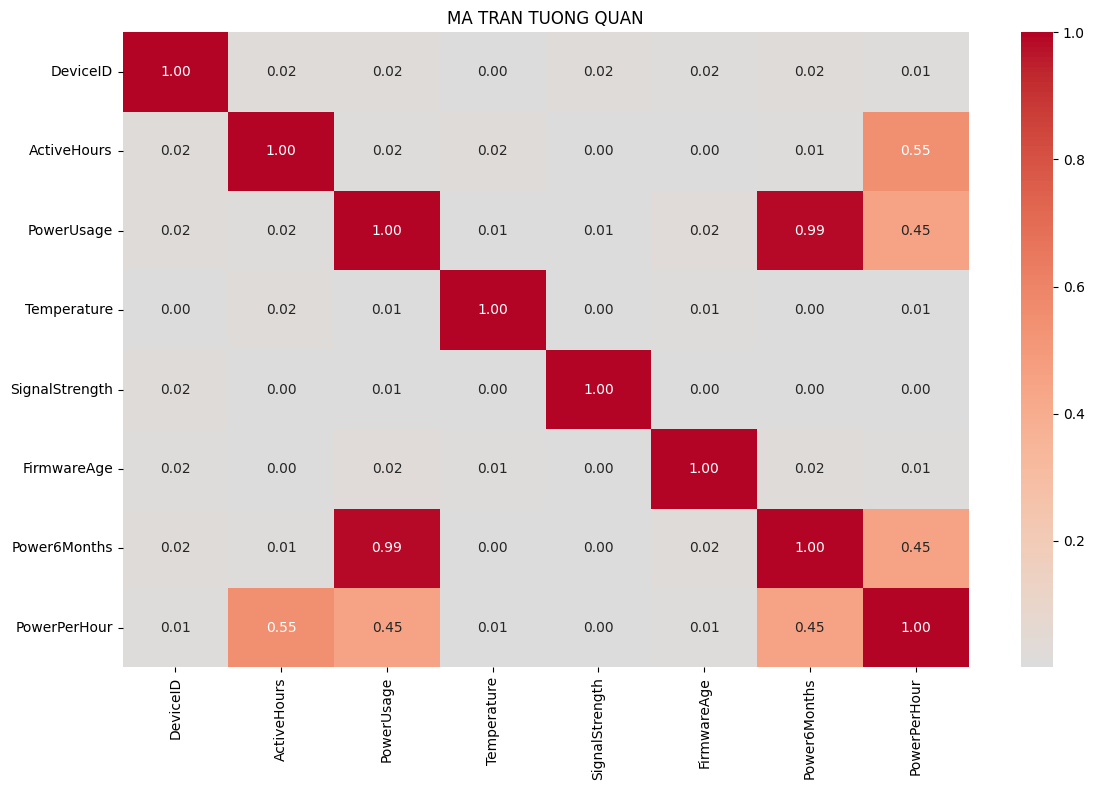

Cac cap thuoc tinh co tuong quan cao (> 0.90):
  Power6Months - PowerUsage: 0.988

Loai bo cac thuoc tinh co tuong quan cao: ['PowerUsage']
CHUAN BI DU LIEU CHO PHAN CUM
Loai bo cac cot: ['DeviceType', 'DeviceID', 'PowerPerHour', 'Power6Months']
Cac features su dung: ['ActiveHours', 'Temperature', 'SignalStrength', 'FirmwareAge']
Du lieu sau chuan hoa: (5000, 4)
HUAN LUYEN KMEANS VOI K = 3
Silhouette Score: 0.245
WCSS: 457.78

Phan phoi cac cum:
Cluster
0    1508
1    2254
2    1238
Name: count, dtype: int64


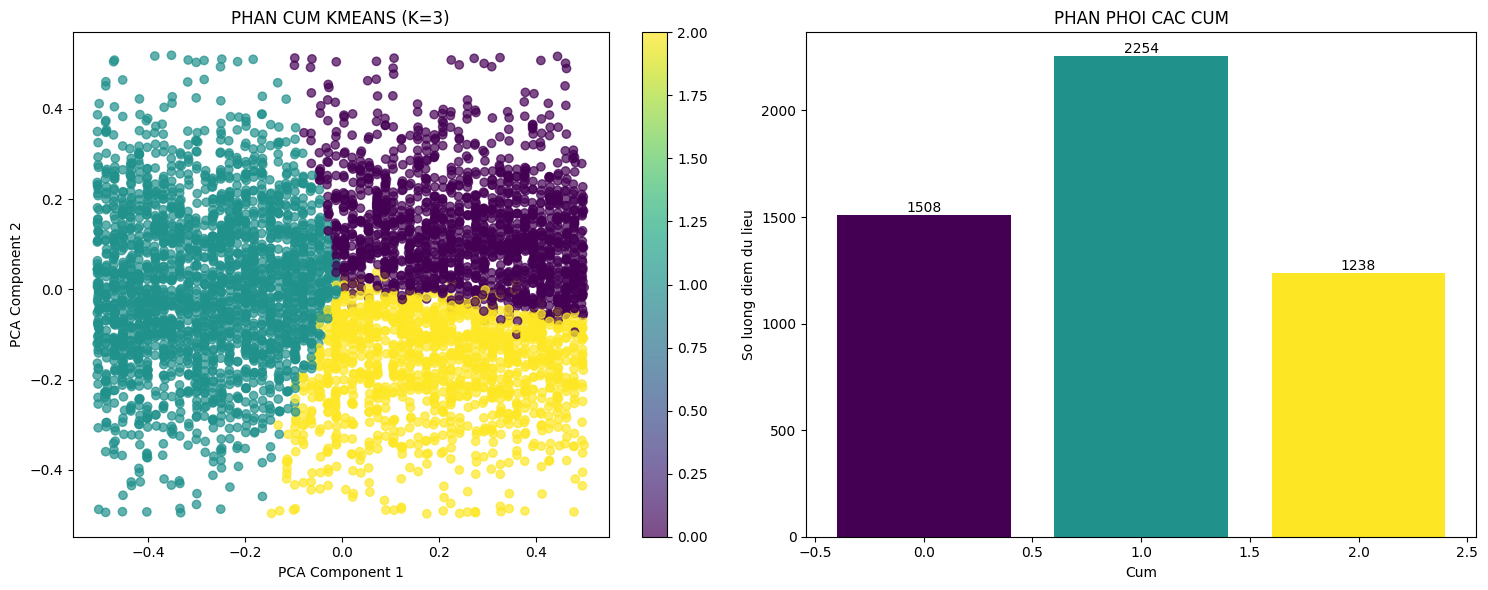


Giai thich phuong sai PCA:
  - Component 1: 0.513
  - Component 2: 0.198
  - Tong: 0.710
PHAN TICH DAC DIEM CAC CUM
Gia tri trung binh cua cac thuoc tinh theo cum:
         DeviceID  ActiveHours  Temperature  SignalStrength  FirmwareAge  \
Cluster                                                                    
0         2468.13        11.72        37.95          -49.44        45.61   
1         2535.59        11.89        38.01          -57.60        14.28   
2         2476.04        12.40        37.89          -69.44        42.61   

         Power6Months  PowerPerHour  
Cluster                              
0           236093.24          5.63  
1           235674.55          5.44  
2           242827.76          5.31  


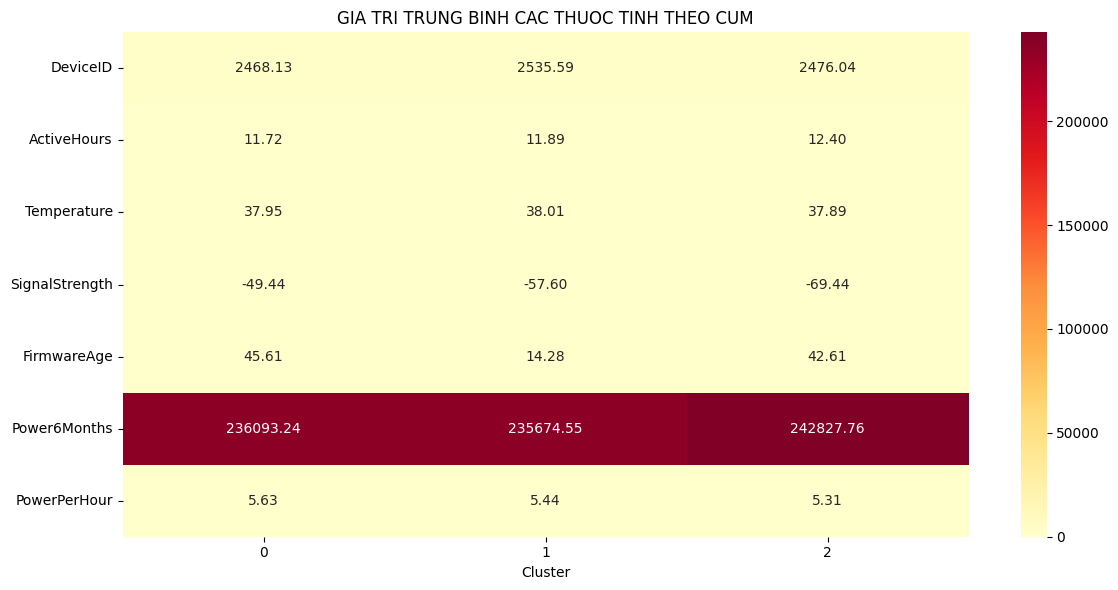

PHAN TICH HOAN TAT!
Dữ liệu được tải thành công. Kích thước: (5000, 9)
Các cột trong dataset: ['DeviceID', 'DeviceType', 'ActiveHours', 'PowerUsage', 'Temperature', 'SignalStrength', 'FirmwareAge', 'Power6Months', 'PowerPerHour']
CHUAN BI DU LIEU CHO PHAN CUM
Loai bo cac cot: ['DeviceType', 'DeviceID', 'PowerPerHour', 'Power6Months']
Cac features su dung: ['ActiveHours', 'PowerUsage', 'Temperature', 'SignalStrength', 'FirmwareAge']
Canh bao: Phat hien gia tri thieu. Tu dong xu ly...
Da tu dong xu ly gia tri thieu con lai
Du lieu sau chuan hoa: (5000, 5)
HUAN LUYEN KMEANS VOI K = 4
Silhouette Score: 0.147
WCSS: 557.35

Phan phoi cac cum:
Cluster
0    1312
1    1257
2    1212
3    1219
Name: count, dtype: int64


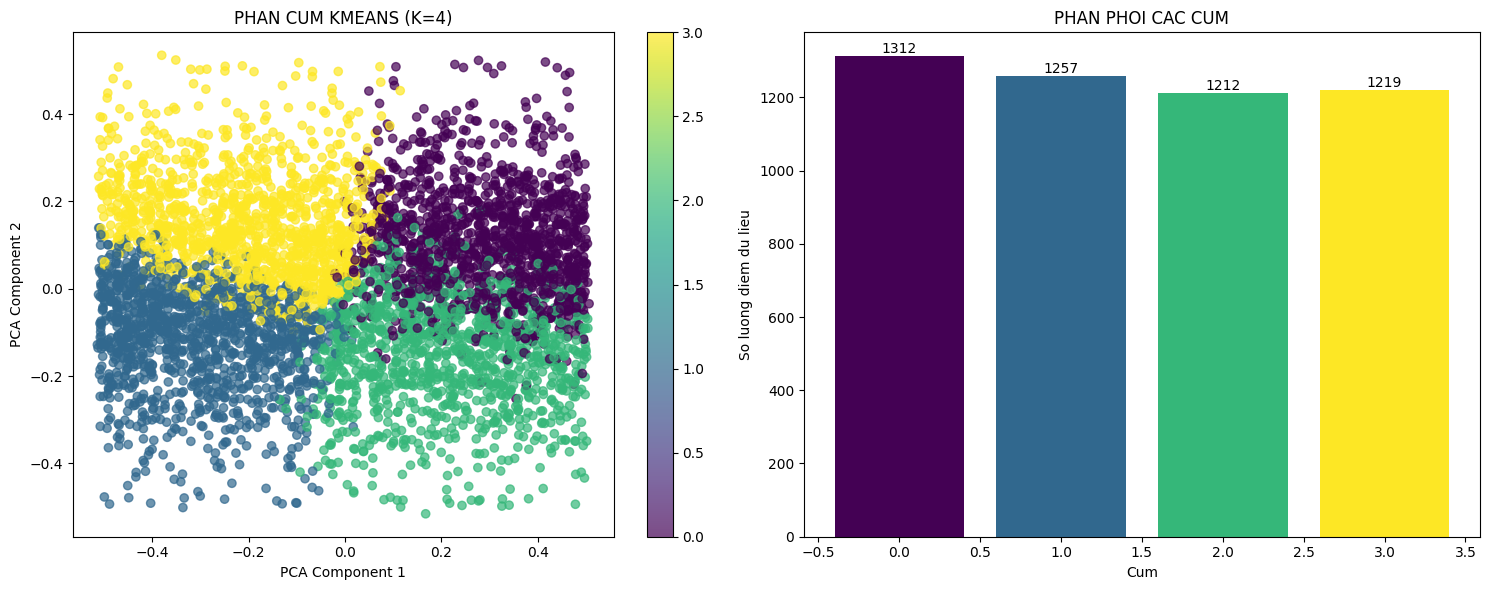


Giai thich phuong sai PCA:
  - Component 1: 0.435
  - Component 2: 0.168
  - Tong: 0.603


In [ ]:
analyzer = KMeansClustering()

# Cách 1: K đơn số với return_type mặc định
model, clusters, analysis = analyzer.full_pipeline(
    file_path="iot_devices.csv",
    k=3  # K đơn số
)

# Cách 2: K đơn số với train_kmeans trực tiếp
analyzer.load_data("iot_devices.csv")
analyzer.prepare_features()
model, clusters = analyzer.train_kmeans(k=4)  # K đơn số

In [ ]:
# Cách 1: Sử dụng pipeline
analyzer = KMeansClustering()
model, clusters, analysis = analyzer.full_pipeline(
    file_path="toy_dataset.csv",
    k=4,
    missing_strategy='median'
)

# Cách 2: Từng bước (đã fix lỗi NaN)
analyzer = KMeansClustering()
analyzer.load_data("toy_dataset.csv")
analyzer.handle_missing_values(strategy='median')  # ĐẢM BẢO XỬ LÝ TRIỆT ĐỂ
analyzer.prepare_features()
model, clusters = analyzer.train_kmeans(k=4)  # SẼ KHÔNG CÒN LỖI NaN

# Cách 3: So sánh nhiều K
results, best_k = analyzer.compare_multiple_k([2, 3, 4, 5, 6])

BAT DAU PHAN TICH PHAN CUM
Dữ liệu được tải thành công. Kích thước: (500, 1000)
Các cột trong dataset: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_6

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x0000020044F75760> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



# cách dùng 

In [ ]:
# chay tu dong
# Khởi tạo analyzer
analyzer = KMeansClustering()

# Chạy toàn bộ pipeline tự động
model, clusters, analysis = analyzer.full_pipeline(
    file_path="dataset.csv",
    k=4,  # Số cụm (có thể để None để tự động tìm)
    missing_strategy='median',  # 'median', 'mean', 'mode'
    corr_threshold=0.9,  # Ngưỡng tương quan để loại bỏ
    scaler_type='minmax',  # 'minmax' hoặc 'standard'
    max_k=10,  # Số K tối đa khi tìm K tối ưu
    return_type='auto'  # 'auto', 'single', 'compare'
)

In [ ]:
# Phân tích nhanh
model, clusters, analysis = quick_kmeans_analysis(
    "data.csv", 
    k=3,
    missing_strategy='mean'
)

# So sánh nhanh nhiều K
results, best_k, analyzer = compare_multiple_k_values(
    "data.csv",
    k_list=[2, 3, 4, 5],
    scaler_type='minmax'
)

In [ ]:
# cách dùng chi tiết nhất 
# Khởi tạo analyzer
analyzer = KMeansClustering()

# Bước 1: Tải dữ liệu
analyzer.load_data("dataset.csv")

# Bước 2: Khám phá dữ liệu
analyzer.explore_data()

# Bước 3: Xử lý giá trị thiếu
analyzer.handle_missing_values(strategy='median')

# Bước 4: Phân tích tương quan
analyzer.analyze_correlation(threshold=0.9)

# Bước 5: Chuẩn bị features
analyzer.prepare_features(exclude_columns=['ID', 'Name'], scaler_type='minmax')

# Bước 6: Tìm K tối ưu
optimal_k, scores = analyzer.find_optimal_k(max_k=10)

# Bước 7: Huấn luyện mô hình
model, clusters = analyzer.train_kmeans(k=optimal_k)

# Bước 8: Phân tích cụm
analysis = analyzer.analyze_clusters()

# dùng nhiều mô hình 

In [ ]:
# So sánh hiệu suất của nhiều giá trị K khác nhau
analyzer = KMeansClustering()
analyzer.load_data("product_data.csv")
analyzer.prepare_features()

# So sánh K từ 2 đến 8
results, best_k = analyzer.compare_multiple_k([2, 3, 4, 5, 6, 7, 8])

print(f"K tốt nhất: {best_k}")
print(f"Silhouette Score: {results[best_k]['silhouette_score']:.4f}")